In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from monodromy.haar import expected_cost, gates_to_haar
from monodromy.render import gates_to_coverage_plot
from numpy import random
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CXGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, gate_error
from qutip import qeye, sigmax, sigmaz, tensor
from scipy.optimize import minimize
from weylchamber import J_T_LI, WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.bgate import BGate
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive

(0.5000309, 0.2500309, 0.0)


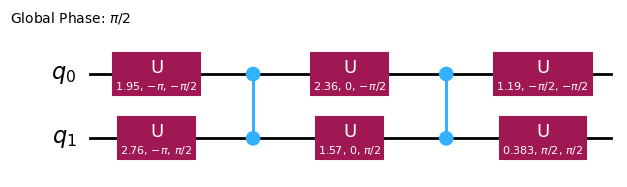

In [2]:
# if we turn a ZZ into a BGate with parallel-drive
# queston is about how expressive it is on that coordinate
# i.e. we can make a locally equivlanet gate to BGate
# but how much flexibility do we have with that unitary?
# 1Qs - B - 1Qs
# we could try introducing more variables
# namely, phases and VZ gates

qc = QuantumCircuit(2)
U = ZZ_ParallelDrive(3 * np.pi / 4, 0, 0, np.pi**2 / 5, np.pi**2 / 5).to_unitary()
qc.append(U, [0, 1])
transp_qc = transpile(qc, basis_gates=["u", "cz"])
transp_qc.draw("mpl")
print(c1c2c3(U))

In [3]:
# can I mess with ZI IZ rates while still making a ~BGate??
# by observation, seems to preserve BGate if only use one ZI but not both

target_gate = BGate().to_matrix()
zi_rate_list = np.linspace(0, np.pi, 50)
parameter_list = []  # ZZ, ZI, IZ, XI, IX


def b_gate_objective(x0):
    U = ZZ_ParallelDrive(x0[0], zi_rate, x0[1], x0[2], x0[3]).to_unitary()
    c1, c2, c3 = c1c2c3(U)
    if c1 > 0.5:
        c1 = 1 - c1

    # return gate_error(U, target_gate)
    return J_T_LI(U.to_matrix(), target_gate)


for zi_rate in zi_rate_list:
    fixed_zz = 3 * np.pi / 4  # Bgate
    x0 = [fixed_zz, 0, np.pi**2 / 5, np.pi**2 / 5]
    result = minimize(b_gate_objective, x0, method="Nelder-Mead")
    # print(result.fun)
    if result.fun >= 1e-10:
        result.success = False
    if not result.success:
        zi_rate_list = zi_rate_list[: len(parameter_list)]
        break
    parameter_list.append((result.x[0], zi_rate, result.x[1], result.x[2], result.x[3]))

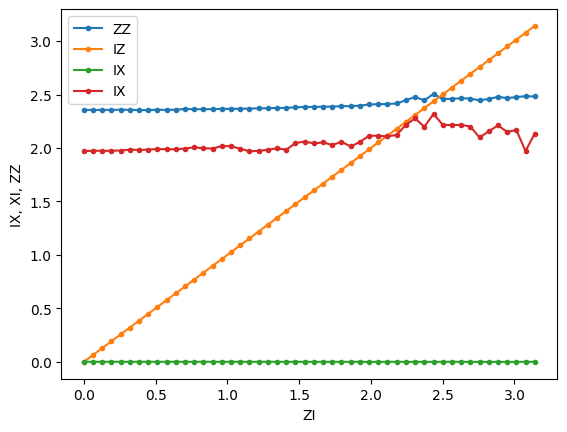

In [4]:
plt.close("all")
plt.plot(zi_rate_list, np.array(parameter_list)[:, 0], marker=".", label="ZZ")
plt.plot(zi_rate_list, np.array(parameter_list)[:, 1], marker=".", label="IZ")
plt.plot(zi_rate_list, np.array(parameter_list)[:, 2], marker=".", label="IX")
plt.plot(zi_rate_list, np.array(parameter_list)[:, 3], marker=".", label="IX")
plt.ylabel("IX, XI, ZZ")
plt.xlabel("ZI")
plt.legend()
plt.show()

(0.50005411, 0.25000001, 1.998e-05)


3.0000000000000004e-16

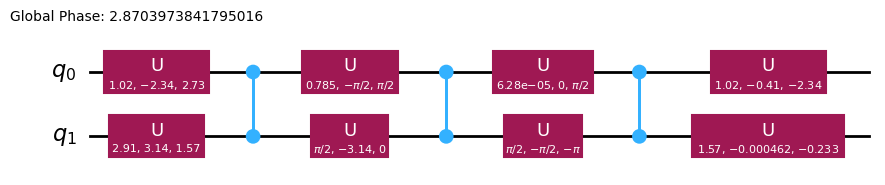

In [5]:
qc = QuantumCircuit(2)
result_index = -1
U = ZZ_ParallelDrive(*parameter_list[result_index]).to_unitary()
qc.append(U, [0, 1])
transp_qc = transpile(qc, basis_gates=["u", "cz"])
transp_qc.draw("mpl")
print(c1c2c3(U))
J_T_LI(U.to_matrix(), target_gate)